# **Hybrid Vehicle Performance**

**Author:** Clayton Morgan

GRADTDA 5505

This dataset was collected over a 1 week period of the performance of a 2025 Ford Maverick hybrid.

`mpg` is the response variable of interest here

---

In [65]:
# %pip install pandas
# %pip install matplotlib
# %pip install seaborn
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

data = pd.read_csv('./maverick_data.csv')

sns.set_style(style="whitegrid")
# plt.style.use('bright')

data['date'] = pd.to_datetime(data['date'])
data['duration'] = pd.to_timedelta('00:' + data['duration'].astype(str), errors='coerce')
data['traffic'] = pd.Categorical(data['traffic'])
data['time_of_day'] = pd.Categorical(data['time_of_day'])

data['highway'] = data['highway'].astype(bool)
data['bed_load'] = data['bed_load'].astype(bool)

In [75]:
# create new col % of drive on electric
data['pct_electric'] = data['miles_electric'] / data['miles_total']
data['pct_gas'] = 1 - data['pct_electric']

data['miles_gas'] = data['miles_total'] - data['miles_electric']

In [76]:
data.describe()

,date,duration,mpg,miles_total,miles_electric,passenger_load,pct_electric,pct_gas,miles_gas
count,33,32,33.000000,33.000000,33.000000,33.000000,33.000000,33.000000,33.000000
mean,2026-06-13 20:21:49.090909,0 days 00:12:10.343750,38.772727,3.303030,1.748485,1.696970,0.586135,0.413865,1.554545
min,2026-06-11 00:00:00,0 days 00:03:42,20.900000,0.700000,0.200000,1.000000,0.145833,0.230769,0.300000
25%,2026-06-12 00:00:00,0 days 00:07:55.750000,32.100000,1.600000,1.000000,1.000000,0.533333,0.302326,0.600000
50%,2026-06-13 00:00:00,0 days 00:12:03,39.000000,2.300000,1.400000,1.000000,0.625000,0.375000,0.800000
75%,2026-06-16 00:00:00,0 days 00:15:55,44.200000,4.300000,2.500000,2.000000,0.697674,0.466667,1.400000
max,2026-06-17 00:00:00,0 days 00:21:57,59.500000,12.200000,4.800000,4.000000,0.769231,0.854167,9.600000
std,NaN,0 days 00:04:40.688394,9.166729,2.671784,1.046160,1.158794,0.164655,0.164655,2.190618


In [77]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 33 entries, 0 to 32
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype          
---  ------          --------------  -----          
 0   date            33 non-null     datetime64[us] 
 1   day_of_week     33 non-null     str            
 2   time_of_day     33 non-null     category       
 3   duration        32 non-null     timedelta64[us]
 4   mpg             33 non-null     float64        
 5   miles_total     33 non-null     float64        
 6   miles_electric  33 non-null     float64        
 7   traffic         33 non-null     category       
 8   highway         33 non-null     bool           
 9   passenger_load  33 non-null     int64          
 10  bed_load        33 non-null     bool           
 11  pct_electric    33 non-null     float64        
 12  pct_gas         33 non-null     float64        
 13  miles_gas       33 non-null     float64        
dtypes: bool(2), category(2), datetime64[us](1), float64(6),

In [79]:
data.head()

,date,day_of_week,time_of_day,duration,mpg,miles_total,miles_electric,traffic,highway,passenger_load,bed_load,pct_electric,pct_gas,miles_gas
0,2026-06-11,Thursday,morning,0 days 00:11:09,38.4,3.5,2.5,moderate,False,1,False,0.714286,0.285714,1.0
1,2026-06-11,Thursday,afternoon,0 days 00:08:13,48.8,1.6,1.1,light,False,1,False,0.687500,0.312500,0.5
2,2026-06-11,Thursday,evening,0 days 00:14:03,44.8,2.6,2.0,light,False,1,False,0.769231,0.230769,0.6
3,2026-06-11,Thursday,evening,0 days 00:09:04,26.6,2.2,1.3,light,False,4,False,0.590909,0.409091,0.9
4,2026-06-11,Thursday,evening,0 days 00:07:45,38.7,2.3,1.2,light,False,4,False,0.521739,0.478261,1.1


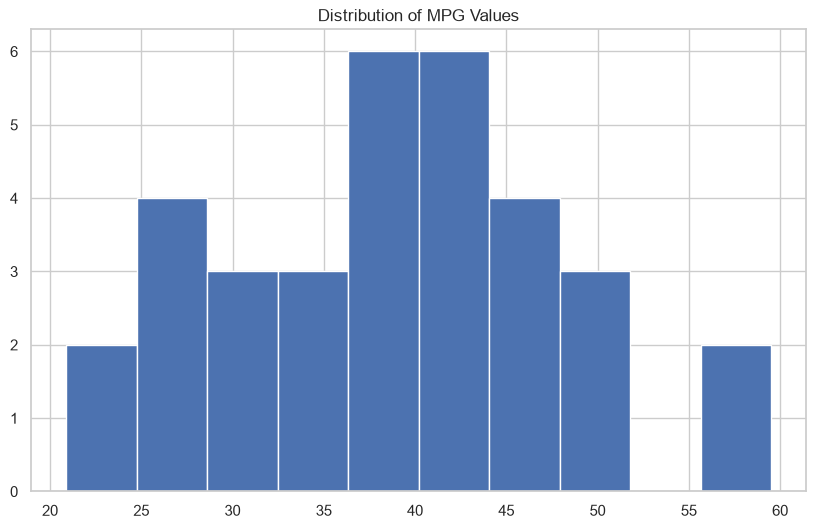

/var/folders/mn/k10b27_x5m5fcgsclrrs62dc0000gn/T/ipykernel_3553/2161129565.py:7: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(x=data['mpg'], vert=False)


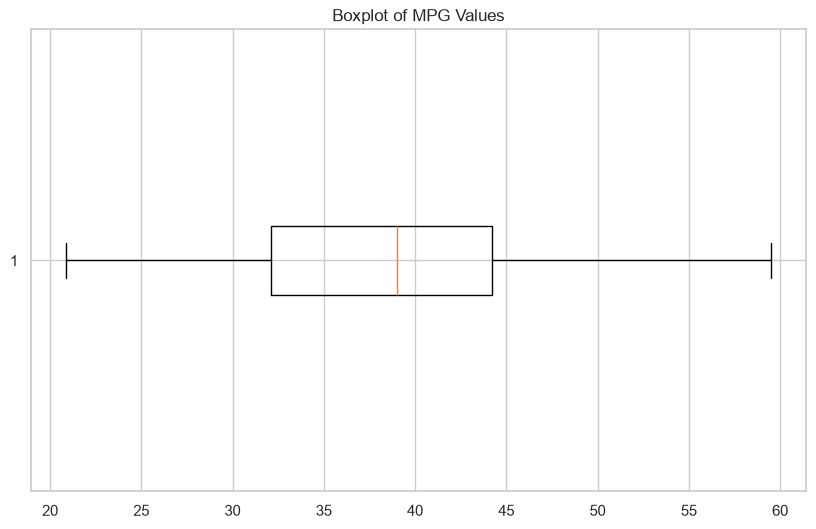

In [57]:
plt.figure(figsize=(10, 6))
plt.hist(x=data['mpg'])
plt.title('Distribution of MPG Values')
plt.show()

plt.figure(figsize=(10, 6))
plt.boxplot(x=data['mpg'], vert=False)
plt.title('Boxplot of MPG Values')
plt.show()

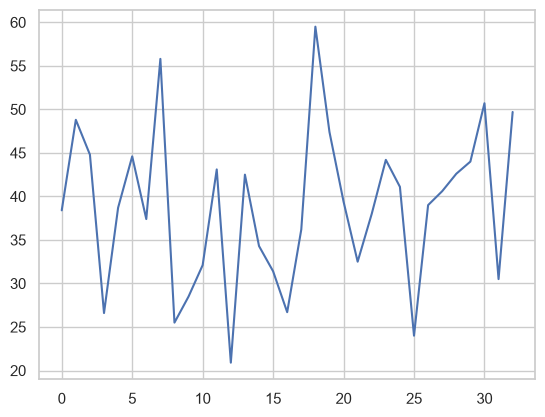

In [58]:
# sequentially plot the mpg values over time to see if there are any trends or patterns
plt.plot(data['mpg'])

*NOTE:* MPG appears to be somewhat sinusoidal in sequnce

/var/folders/mn/k10b27_x5m5fcgsclrrs62dc0000gn/T/ipykernel_3553/2121617509.py:9: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(morning_data['mpg'], label='Morning', vert=False)


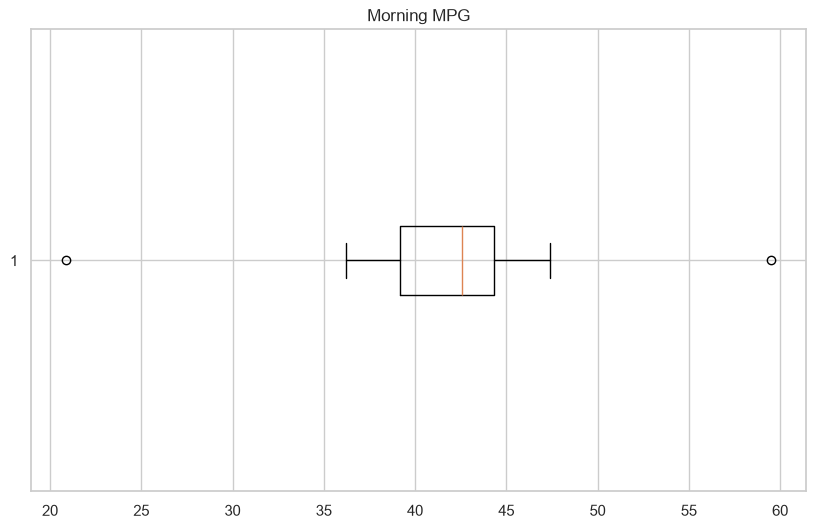

/var/folders/mn/k10b27_x5m5fcgsclrrs62dc0000gn/T/ipykernel_3553/2121617509.py:14: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(afternoon_data['mpg'], label='Afternoon', vert=False)


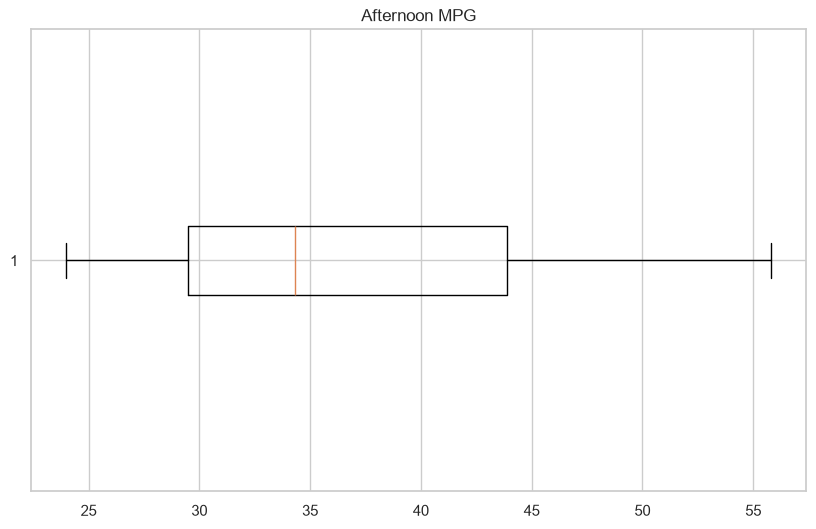

/var/folders/mn/k10b27_x5m5fcgsclrrs62dc0000gn/T/ipykernel_3553/2121617509.py:19: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(evening_data['mpg'], label='Evening', vert=False)


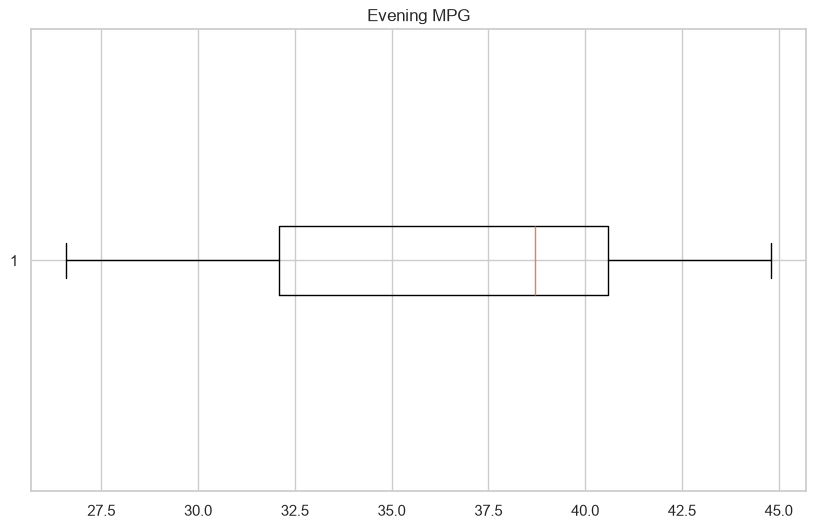

/var/folders/mn/k10b27_x5m5fcgsclrrs62dc0000gn/T/ipykernel_3553/2121617509.py:24: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(night_data['mpg'], label='Night', vert=False)


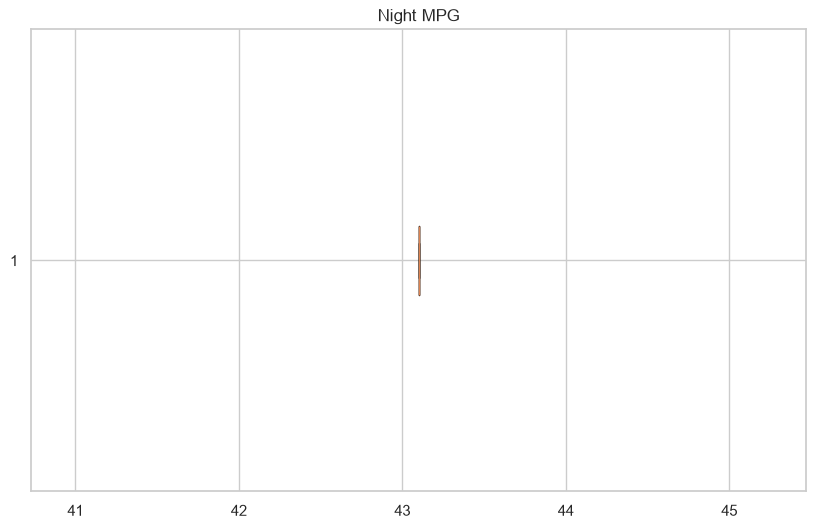

In [62]:
# split up into time of day based on MPG
morning_data = data[data['time_of_day'] == 'morning']
afternoon_data = data[data['time_of_day'] == 'afternoon']
evening_data = data[data['time_of_day'] == 'evening']
night_data = data[data['time_of_day'] == 'night']

# plot the MPG for each
plt.figure(figsize=(10, 6))
plt.boxplot(morning_data['mpg'], label='Morning', vert=False)
plt.title('Morning MPG')
plt.show()

plt.figure(figsize=(10, 6))
plt.boxplot(afternoon_data['mpg'], label='Afternoon', vert=False)
plt.title('Afternoon MPG')
plt.show()

plt.figure(figsize=(10, 6))
plt.boxplot(evening_data['mpg'], label='Evening', vert=False)
plt.title('Evening MPG')
plt.show()

plt.figure(figsize=(10, 6))
plt.boxplot(night_data['mpg'], label='Night', vert=False)
plt.title('Night MPG')
plt.show()

**Note:** Only 1 observation in night category, will not use night as a category for visualizations

In [ ]:
# split traffic levels into categories and plot the MPG for each
